# 🧊 04-Adam 变体与解耦权重衰减

> 目标：把「权重衰减」和「L2 正则」掰开——**为什么 Adam 里它们不一样**（AdamW 解耦），
> 以及大模型训练锁死 AdamW 的原因；顺带过 NAdam / AMSGrad / LAMB / Lion。

## §1 L2 正则与 Adam 的耦合问题

朴素做法（Adam+L2）：$g \gets g + \lambda w$，再进 Adam。

问题：权重大 → 梯度项大 → $\sqrt{\hat v}$ 大 → **L2 贡献被自适应步长缩小**。
即**正则化强度被参数幅度反向调制**，大权重几乎不衰减——与「权重衰减应一视同仁」的初衷矛盾。

**AdamW（Loshchilov & Hutter 2019）**：把衰减从梯度里拿出来，直接乘到参数上：

$$\boxed{\;w \gets w - \eta\,\hat m_t/(\sqrt{\hat v_t}+\epsilon) - \eta\lambda w\; }$$

> 第二项与梯度无关：无论自适应步长如何，权重都按固定比例 $\eta\lambda$ 衰减。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 手写 Adam（可切换 L2 / 解耦衰减） ----------
class AdamWithDecay:
    def __init__(self, lr=0.01, b1=0.9, b2=0.999, eps=1e-8, wd=0.0, decoupled=False):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.wd, self.decoupled = wd, decoupled
        self.m = self.v = None
    def step(self, w, g, t):
        t1 = t + 1
        g_eff = g + self.wd * w if not self.decoupled else g   # L2：进梯度；解耦：不进
        self.m = (1 - self.b1) * g_eff if self.m is None else self.b1 * self.m + (1 - self.b1) * g_eff
        self.v = (1 - self.b2) * g_eff * g_eff if self.v is None else self.b2 * self.v + (1 - self.b2) * g_eff * g_eff
        m_hat = self.m / (1 - self.b1**t1)
        v_hat = self.v / (1 - self.b2**t1)
        w_new = w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        if self.decoupled:
            w_new = w_new - self.lr * self.wd * w
        return w_new

In [2]:
# ---------- 实验 1：手写 AdamW vs torch.optim.AdamW 逐位对照 ----------
import torch

torch.manual_seed(7)
w_t = torch.randn(4, 4, dtype=torch.float64, requires_grad=True)
w_n = w_t.detach().numpy().copy()

opt_t = torch.optim.AdamW([w_t], lr=0.01, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01)
mine = AdamWithDecay(lr=0.01, b1=0.9, b2=0.999, eps=1e-8, wd=0.01, decoupled=True)

maxdiff = 0.0
for t in range(15):
    g = torch.randn(4, 4, dtype=torch.float64)
    (w_t * g).sum().backward()
    opt_t.step(); opt_t.zero_grad()
    w_n = mine.step(w_n, g.numpy(), t)
    maxdiff = max(maxdiff, np.abs(w_n - w_t.detach().numpy()).max())
print(f'手写 AdamW vs torch.optim.AdamW 最大误差: {maxdiff:.2e}')
assert maxdiff < 1e-12
print('对照通过')

手写 AdamW vs torch.optim.AdamW 最大误差: 1.11e-15
对照通过


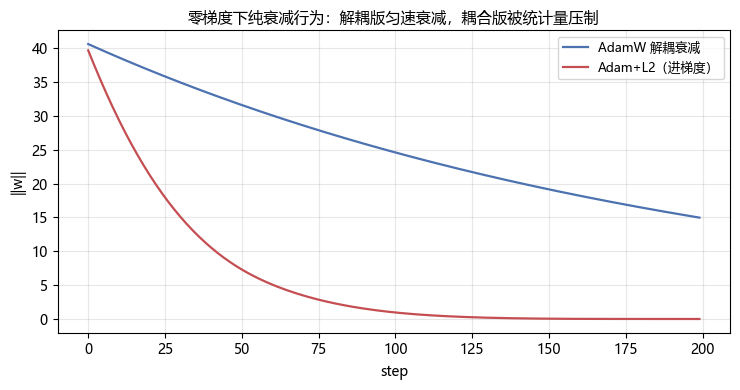

解耦衰减按固定比例缩；耦合衰减首步 v=0 时几乎不动


In [3]:
# ---------- 实验 2：解耦 vs 耦合衰减对大权重的影响 ----------
rng = np.random.default_rng(0)
w = rng.normal(scale=3.0, size=200)   # 大初始权重
g = np.zeros_like(w)                  # 无梯度（看纯衰减行为）

def pure_decay(decoupled, steps=200, lr=0.1, wd=0.05):
    o = AdamWithDecay(lr=lr, wd=wd, decoupled=decoupled)
    ww = w.copy(); norms = []
    for t in range(steps):
        ww = o.step(ww, g, t)
        norms.append(np.linalg.norm(ww))
    return np.array(norms)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(pure_decay(True),  label='AdamW 解耦衰减', color='#4C72B0', lw=1.6)
ax.plot(pure_decay(False), label='Adam+L2（进梯度）', color='#C44E52', lw=1.6)
ax.set_xlabel('step'); ax.set_ylabel('||w||')
ax.set_title('零梯度下纯衰减行为：解耦版匀速衰减，耦合版被统计量压制', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('解耦衰减按固定比例缩；耦合衰减首步 v=0 时几乎不动')

## §2 变体总表（面试背诵）

| 变体 | 改动 | 解决什么 |
|------|------|----------|
| **AdamW** | 权重衰减解耦：`w -= lr*wd*w` | L2 与自适应步长耦合 → **LLM 默认** |
| NAdam | 一阶矩带 Nesterov 前瞻 | Adam 收敛再快一点 |
| AMSGrad | $\hat v = \max(\hat v_{t-1}, \hat v_t)$（单调不减） | 防 Adam 在非凸问题上步长反复增大 |
| **LAMB** | 逐层步长归一：`lr * ||w|| / ||m_hat/(sqrt(v_hat)+eps)||` | 大 batch（数千）训练不炸 |
| **Lion** | `w -= lr * sign(b1*m + (1-b1)*g)` | 省显存省算力，只用符号 |
| Adafactor | 二阶矩按行/列分解近似 | 省内存（T5 用） |

## §3 为什么大模型锁死 AdamW

- 权重衰减解耦 → 正则强度不受幅度调制，训练更稳
- 配合 warmup + cosine + 梯度裁剪（05 篇）成为 LLM 训练标配（GPT / LLaMA 系）
- AdamW 在 Transformer 上普遍优于 Adam+L2（正则化与自适应解耦）

## §4 常见 bug 与边界

- **PyTorch 默认**：`optim.AdamW` 的 `weight_decay` 默认走解耦路径，不要和 L2 混写
- **decoupled 衰减不放梯度里**：放梯度里就不是 AdamW 了
- **Lion 无二阶矩**：不存 $v$，省一半优化器内存；但超参（lr 通常更小）要重新调

## §5 面试追问与扩展

1. **LAMB 为什么能大 batch**：每层梯度范数差异大，按参数范数归一化步长，避免某层被压死
2. **Adafactor 省多少**：二阶矩从 $O(n)$ 降为 $O(\sqrt n)$（行+列因子）
3. **AdamW vs SGD+wd**：对小模型差异小，对 Transformer 明显

## §6 自测清单

- [ ] 默写 AdamW 更新公式（衰减项写在参数更新里）
- [ ] 解释「L2 与自适应步长耦合」的机制
- [ ] 手写 AdamW 与 torch 对照（本文已断言）
- [ ] 一句话说清 LAMB / Lion / AMSGrad 各改了什么
- [ ] 为什么 LLM 训练默认 AdamW

> 💡 下节预告：学习率调度（warmup/cosine）与梯度裁剪/累积（05 篇）。